In [1]:
import sys; sys.path.append("scripts")
from load_parquet_data import load_parquet
era5 = load_parquet("ERA5")


In [2]:
era5.head(3)

,time,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl
0,1980-01-01,-30.0,120.0,-0.157461,0.001843,-24030192.0,NaN,302.30980,100920.375
1,1980-01-01,-30.0,122.0,-0.160635,0.015271,-24052208.0,NaN,301.18090,100998.125
2,1980-01-01,-30.0,124.0,-0.098501,0.038526,-24364784.0,NaN,300.44263,101090.500


In [3]:
era5.describe()

,time,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl
count,1398627,1.398627e+06,1.398627e+06,1.398627e+06,1.398627e+06,1.398627e+06,1.275530e+06,1.398627e+06,1.398627e+06
mean,2003-03-02 07:27:15.188509,0.000000e+00,2.000000e+02,-4.543197e-02,3.006749e-03,-2.274049e+07,2.992703e+02,2.976173e+02,1.013253e+05
min,1980-01-01 00:00:00,-3.000000e+01,1.200000e+02,-1.214612e+00,-8.906822e-01,-2.784126e+07,2.838455e+02,2.738076e+02,1.000191e+05
25%,1991-08-01 00:00:00,-1.600000e+01,1.600000e+02,-7.506943e-02,-1.642799e-02,-2.437277e+07,2.974568e+02,2.958657e+02,1.010292e+05
50%,2003-03-01 00:00:00,0.000000e+00,2.000000e+02,-4.533672e-02,2.184868e-03,-2.307474e+07,3.000364e+02,2.987202e+02,1.012439e+05
75%,2014-10-01 00:00:00,1.600000e+01,2.400000e+02,-1.576519e-02,2.287197e-02,-2.143781e+07,3.016609e+02,3.000410e+02,1.015865e+05
max,2026-05-01 00:00:00,3.000000e+01,2.800000e+02,8.912992e-01,6.666050e-01,-1.242472e+07,3.053018e+02,3.096585e+02,1.030612e+05
std,NaN,1.788855e+01,4.676182e+01,5.312794e-02,3.972991e-02,2.091728e+06,3.036282e+00,3.343414e+00,3.844733e+02


In [4]:
era5.info()

<class 'pandas.DataFrame'>
RangeIndex: 1398627 entries, 0 to 1398626
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   time       1398627 non-null  datetime64[us]
 1   latitude   1398627 non-null  float64       
 2   longitude  1398627 non-null  float64       
 3   avg_iews   1398627 non-null  float64       
 4   avg_inss   1398627 non-null  float64       
 5   ttr        1398627 non-null  float64       
 6   sst        1275530 non-null  float64       
 7   t2m        1398627 non-null  float64       
 8   msl        1398627 non-null  float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 96.0 MB


In [6]:
era5['sst'].isna().sum()


np.int64(123097)

In [7]:
era5['sst'].count()

np.int64(1275530)

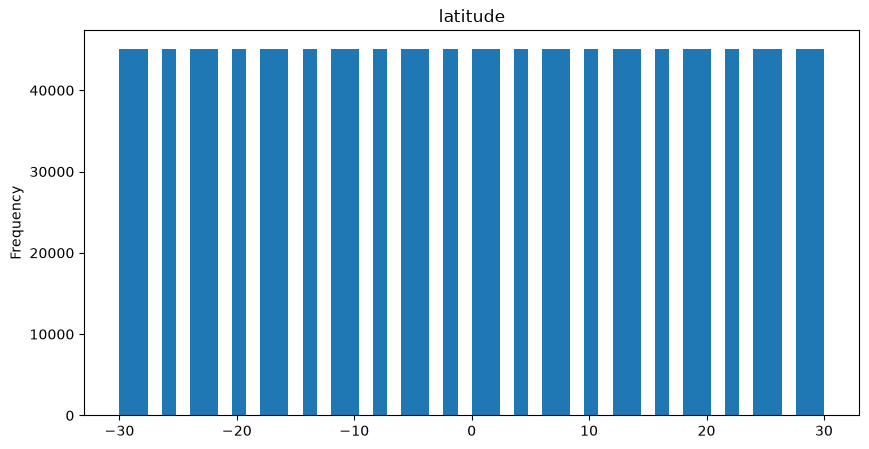

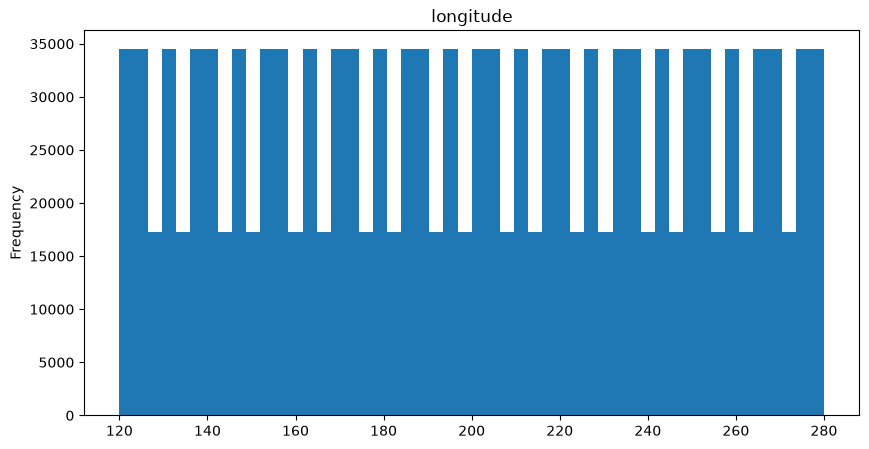

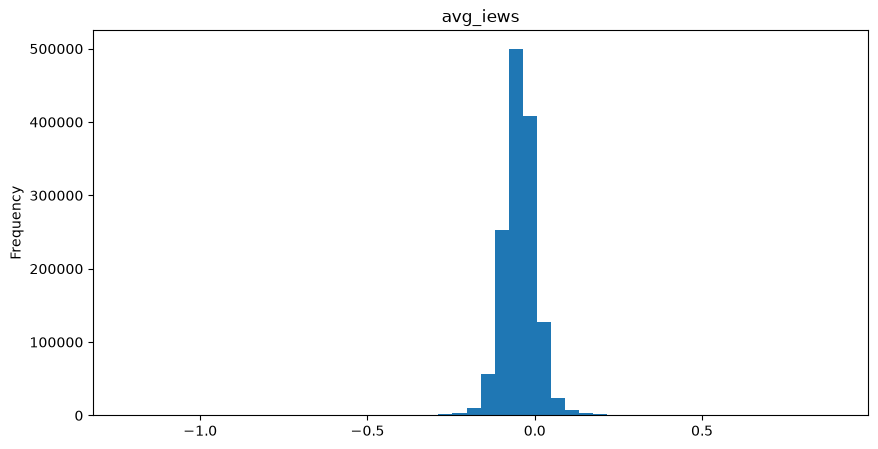

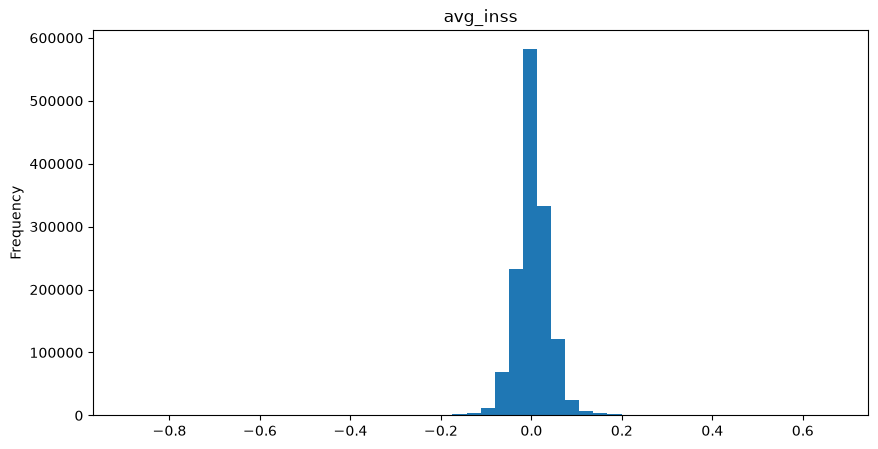

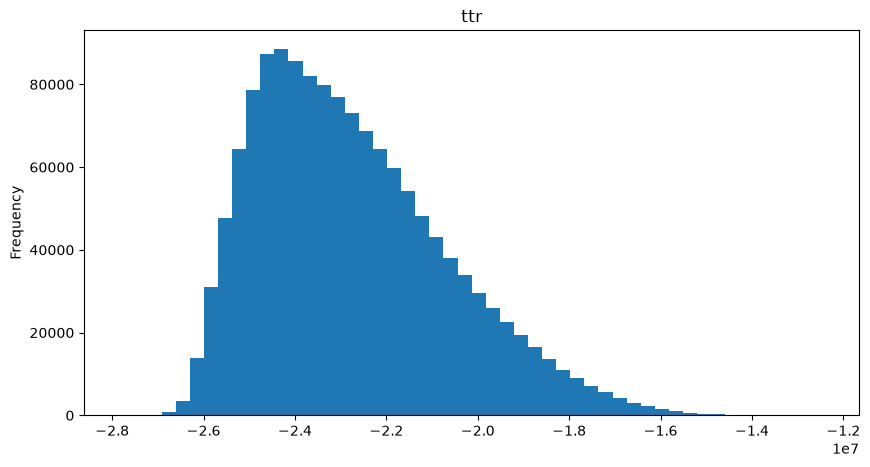

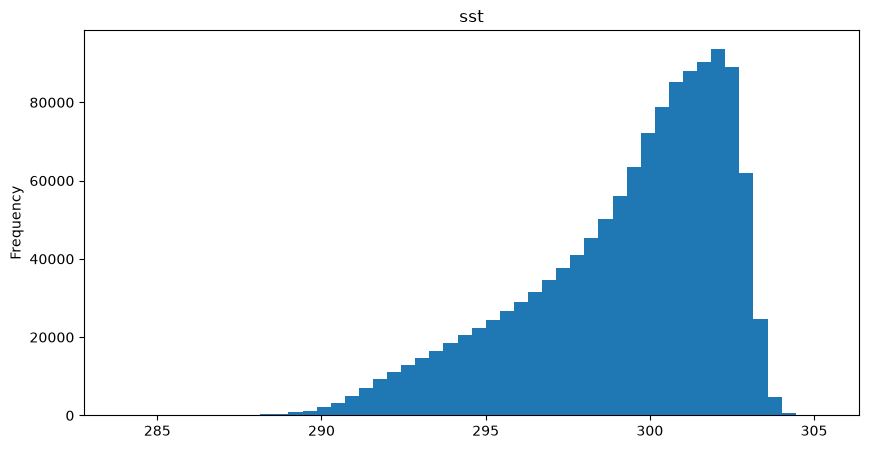

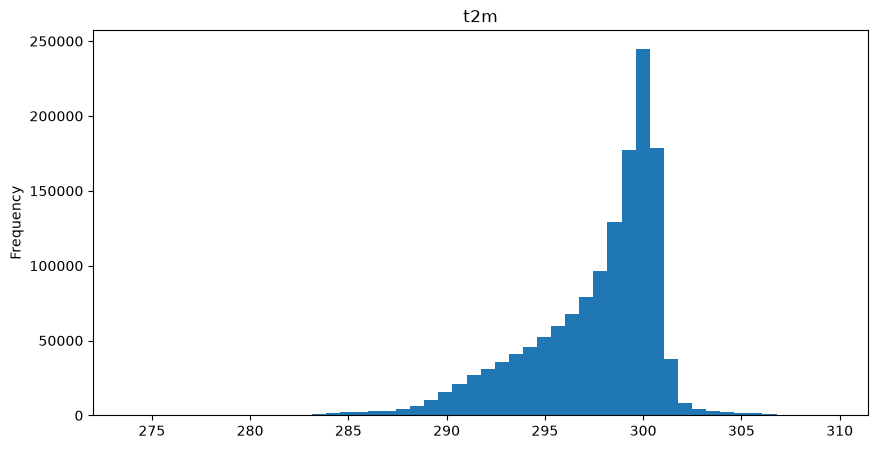

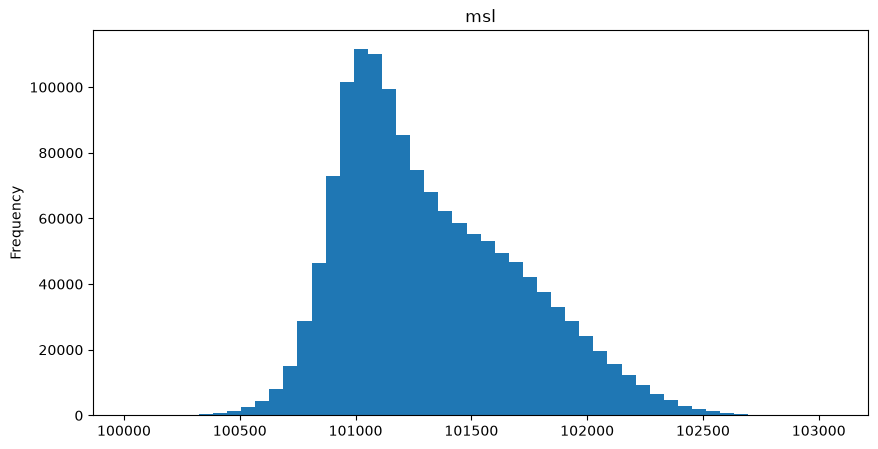

In [12]:
import matplotlib.pyplot as plt

for col in era5.select_dtypes(include='number').columns:
    era5[col].plot(title=col, kind='hist', bins=50, figsize=(10, 5))
    plt.show()


## Stratified Sampling with Class-Imbalance Handling

The ERA5 variables are continuous, so we create discrete strata from `sst`
(sea-surface temperature, the key El Niño signal) using fixed-width temperature
bands. Fixed-width bands produce a naturally imbalanced class distribution.
We then draw a **balanced** stratified sample (equal rows per stratum,
over-/under-sampling as needed) and plot each variable's histogram together
with a fitted normal-distribution curve.


Rows per stratum (class imbalance):
sst_stratum
(283.824, 287.422]       359
(287.422, 290.998]     11252
(290.998, 294.574]    112148
(294.574, 298.15]     261552
(298.15, 301.726]     584971
(301.726, 305.302]    305248
Name: count, dtype: int64


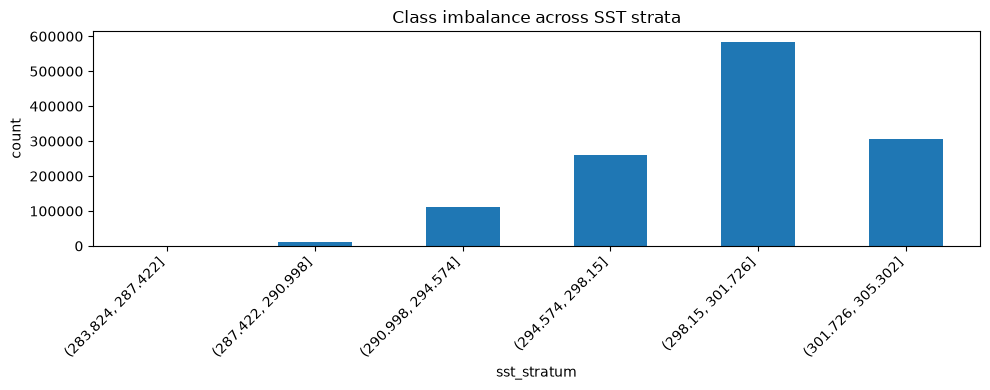

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Stratify on sea-surface temperature (key El Niño variable)
df = era5.dropna(subset=['sst']).copy()

# Fixed-width temperature bands -> naturally imbalanced strata
df['sst_stratum'] = pd.cut(df['sst'], bins=6)

class_counts = df['sst_stratum'].value_counts().sort_index()
print("Rows per stratum (class imbalance):")
print(class_counts)

class_counts.plot(kind='bar', figsize=(10, 4),
                  title='Class imbalance across SST strata')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [16]:
# Balanced stratified sample: equal rows per stratum to remove class imbalance.
# Strata smaller than the target are oversampled (with replacement),
# larger strata are undersampled (without replacement).
target = int(class_counts.median())

balanced_sample = (
    df.groupby('sst_stratum', observed=True, group_keys=False)[list(df.columns)]
      .apply(lambda g: g.sample(n=target,
                                replace=len(g) < target,
                                random_state=42))
      .reset_index(drop=True)
)

print(f"Balanced sample size: {len(balanced_sample)} "
      f"({target} rows per stratum)")
print(balanced_sample['sst_stratum'].value_counts().sort_index())


Balanced sample size: 1121100 (186850 rows per stratum)
sst_stratum
(283.824, 287.422]    186850
(287.422, 290.998]    186850
(290.998, 294.574]    186850
(294.574, 298.15]     186850
(298.15, 301.726]     186850
(301.726, 305.302]    186850
Name: count, dtype: int64


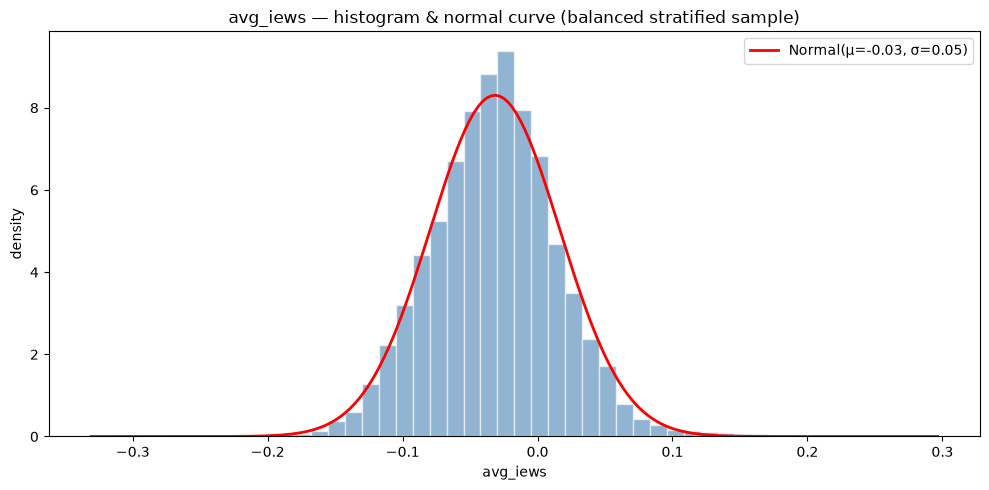

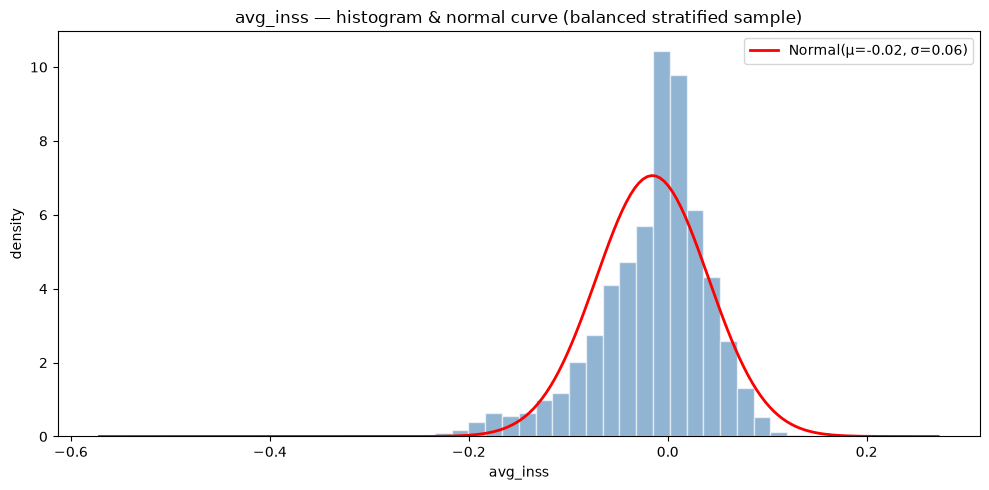

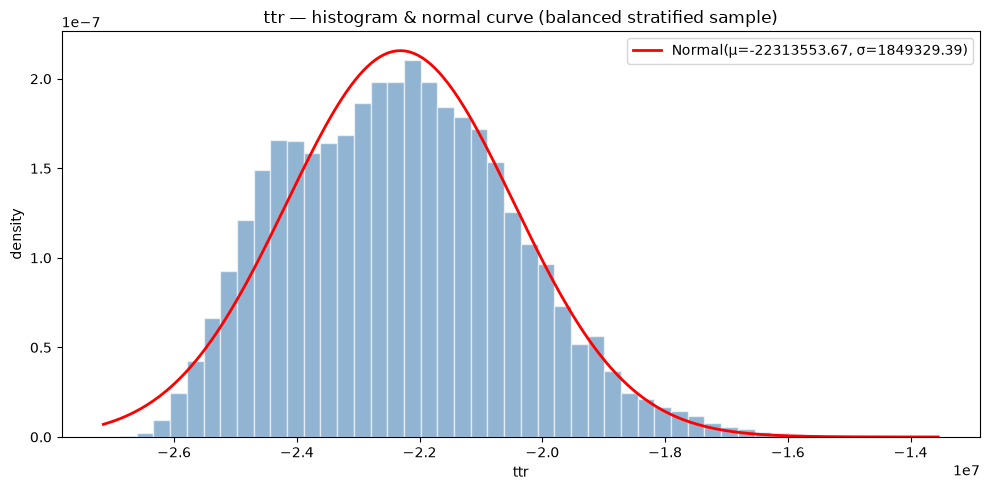

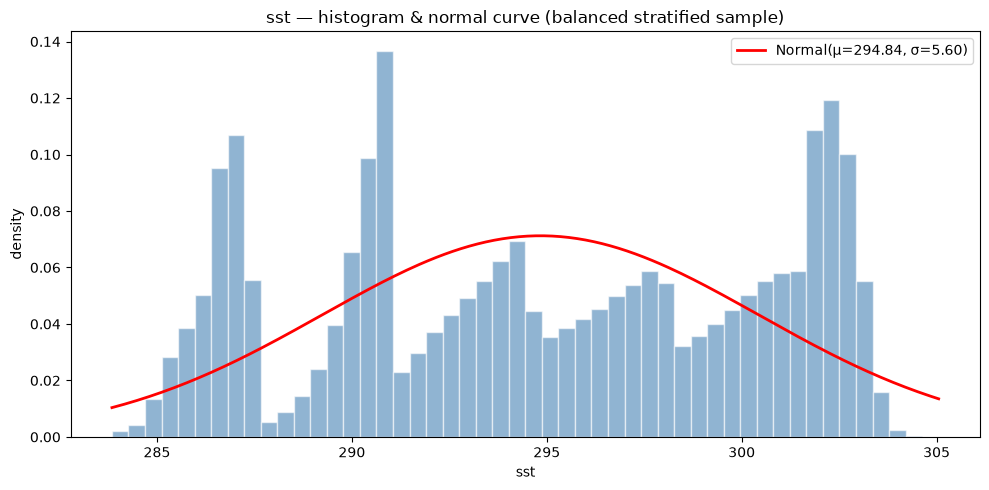

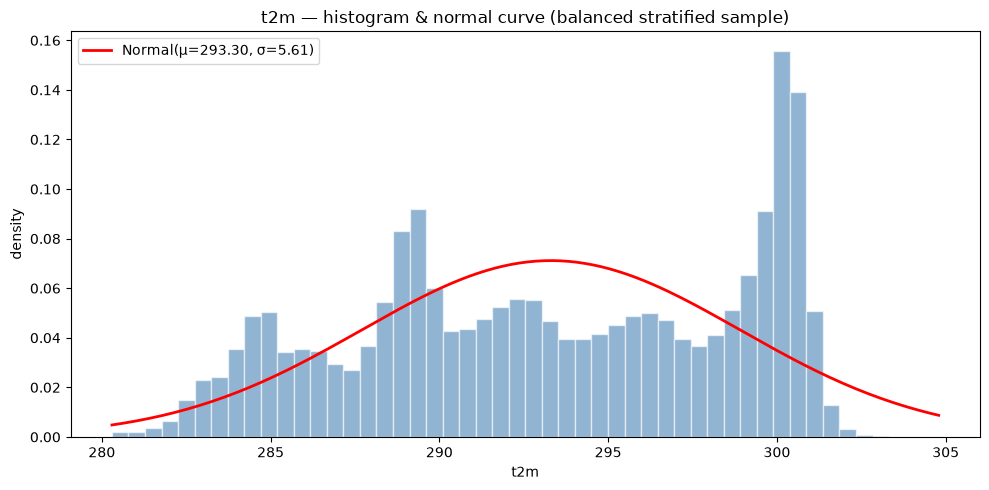

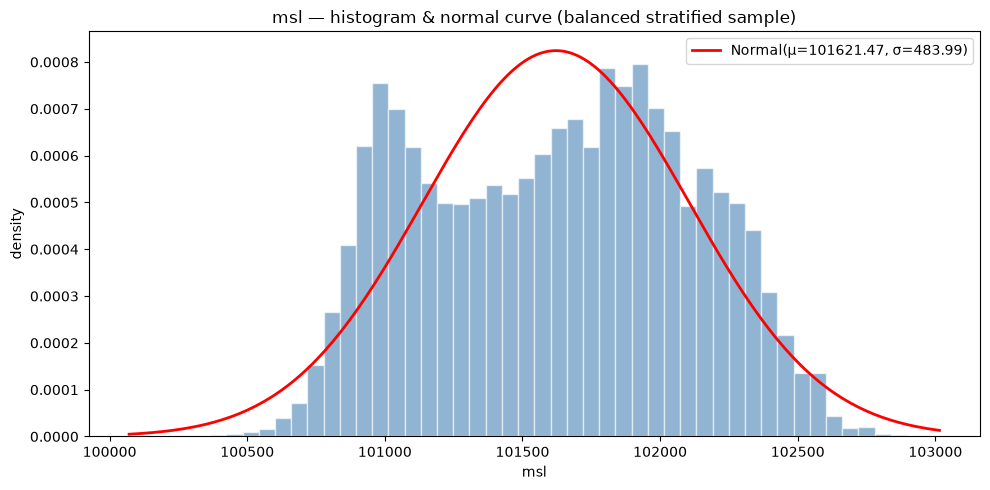

In [17]:
# Histogram + fitted normal-distribution curve for each climate variable
plot_cols = [c for c in balanced_sample.select_dtypes(include='number').columns
             if c not in ('latitude', 'longitude')]

for col in plot_cols:
    data = balanced_sample[col].dropna()
    mu, sigma = data.mean(), data.std()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(data, bins=50, density=True, alpha=0.6,
            color='steelblue', edgecolor='white')

    x = np.linspace(data.min(), data.max(), 200)
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax.plot(x, pdf, 'r-', lw=2, label=f'Normal(μ={mu:.2f}, σ={sigma:.2f})')

    ax.set_title(f'{col} — histogram & normal curve (balanced stratified sample)')
    ax.set_xlabel(col)
    ax.set_ylabel('density')
    ax.legend()
    plt.tight_layout()
    plt.show()
